# Stage 1 - Raw Data Understanding

This notebook looks at the telecom churn dataset **exactly as it arrives**, before
any cleaning. The goal is to understand what we are working with: how big it is,
what each column means, what the target looks like, and where the data is messy.

Following the reference style: we show the evidence first, then write a short
plain-English conclusion under each output.

All reusable logic lives in `src/`; this notebook only calls it and explains the
results.

In [1]:
import sys
from pathlib import Path

# Make the project's src/ package importable no matter where the notebook is launched.
here = Path.cwd()
project_root = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(project_root))

import pandas as pd

from src.config import FIGURES_DIR, ID_COLUMN, TARGET_COLUMN, NUMERIC_COLUMNS, CATEGORICAL_COLUMNS
from src.data.load import load_raw_data
from src.visualization import raw_plots

pd.set_option("display.max_columns", None)

## 1. Load the data and check its size

In [2]:
df = load_raw_data()
print("Rows, columns:", df.shape)

Rows, columns: (7043, 21)


**Conclusion:** The dataset has 7,043 customers and 21 columns. That is a
comfortable size for the models we plan to use, and large enough to keep a
separate validation and test set later.

## 2. First look at the rows

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Each row is one customer. The columns fall into a few groups:

| Group | Columns | Meaning |
|---|---|---|
| Identifier | `customerID` | Unique customer code (not a real feature) |
| Demographics | `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Who the customer is |
| Account | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod` | How they pay and how long they have stayed |
| Services | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Which products they use |
| Charges | `MonthlyCharges`, `TotalCharges` | How much they are billed |
| Target | `Churn` | Whether the customer left (Yes/No) |

**Conclusion:** The data mixes numeric and categorical columns, so later stages
will need to handle both types.

## 3. Data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Conclusion:** Most columns are text (`object`), which is expected for
categorical fields. The important surprise is **`TotalCharges`**: it is stored as
text even though it represents money. We investigate that below. `tenure` and
`MonthlyCharges` are already numeric, and `SeniorCitizen` is stored as 0/1.

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Conclusion:** Tenure ranges from 0 to 72 months and monthly charges from
about \$18 to \$119. `TotalCharges` is missing from the numeric summary because
it is still text at this point.

## 4. Target distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


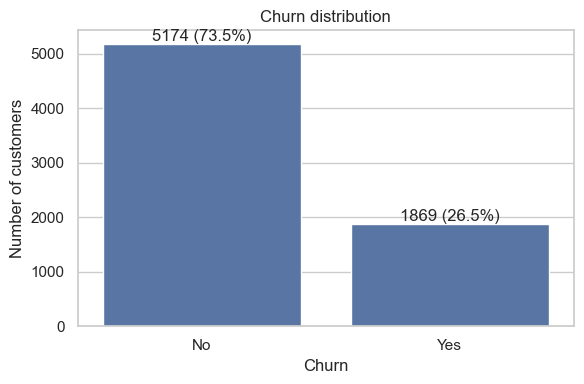

In [6]:
print(df[TARGET_COLUMN].value_counts())
print()
print((df[TARGET_COLUMN].value_counts(normalize=True) * 100).round(1))

fig = raw_plots.plot_target_distribution(df)
fig.savefig(FIGURES_DIR / "raw_churn_distribution.png", dpi=120, bbox_inches="tight")

**Conclusion:** About **26.5%** of customers churned and **73.5%** stayed.
The classes are imbalanced but not extreme. This matters: accuracy alone would be
misleading (always predicting "No" already scores ~73%), so Stage 3 will use
precision, recall, F1, and ROC/PR-AUC, and will test class weighting and SMOTE.

## 5. Missing values

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Conclusion:** Pandas reports **no** missing values. But that is only
because the blanks in `TotalCharges` are stored as empty text, not as NaN. We
check for those directly.

In [8]:
blank_total_charges = (df["TotalCharges"].str.strip() == "").sum()
print("Blank TotalCharges values:", blank_total_charges)

# Who are these customers? Look at their tenure.
print()
print(df.loc[df["TotalCharges"].str.strip() == "", ["tenure", "MonthlyCharges", "TotalCharges"]])

Blank TotalCharges values: 11

      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             
3331       0           19.85             
3826       0           25.35             
4380       0           20.00             
5218       0           19.70             
6670       0           73.35             
6754       0           61.90             


**Conclusion:** There are **11** rows where `TotalCharges` is blank, and
every one of them has `tenure = 0`. These are brand-new customers who have not
been billed a full total yet. This is a real data-quality issue to fix in Stage 2
(for example, convert the column to numeric and set these totals to 0), not random
noise to drop blindly.

## 6. Duplicate rows and duplicate customer IDs

In [9]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customer IDs:", df[ID_COLUMN].duplicated().sum())

Fully duplicated rows: 0
Duplicated customer IDs: 0


**Conclusion:** There are no duplicate rows and no repeated customer IDs, so
each row is a distinct customer. No de-duplication is needed.

## 7. Numeric distributions

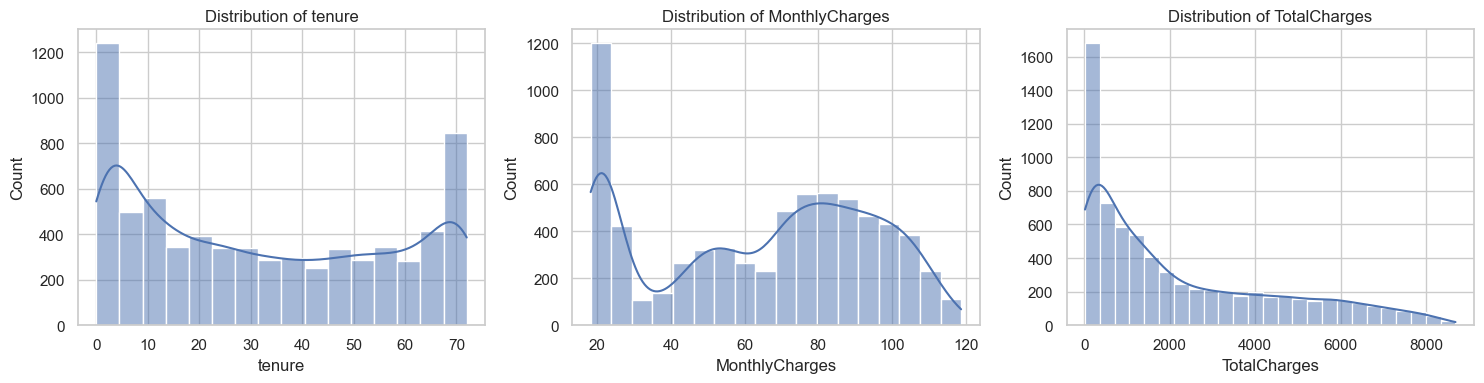

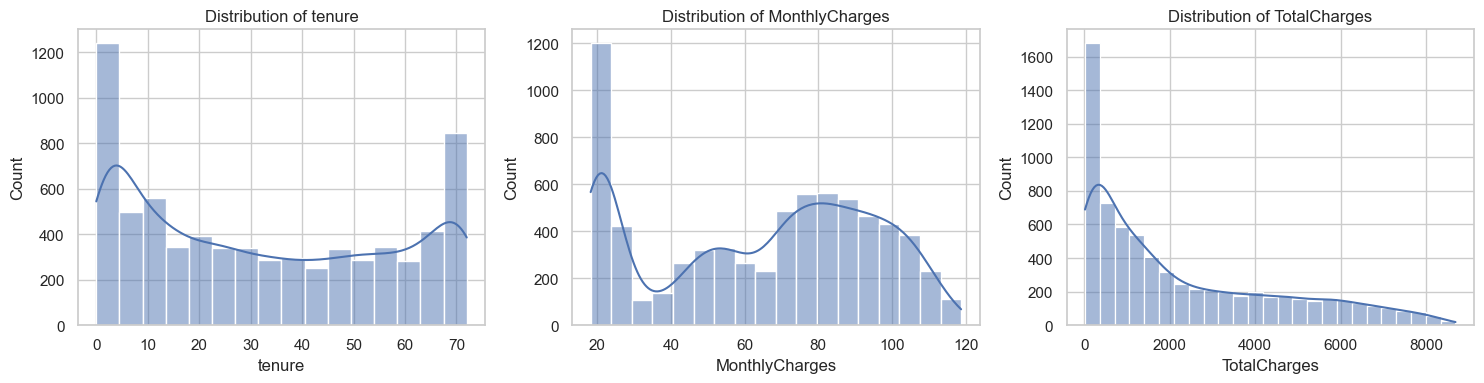

In [10]:
raw_plots.plot_numeric_distributions(df)

**Conclusion:**
- **tenure** is U-shaped: many customers are either very new or long-standing.
- **MonthlyCharges** has a large group around \$20 (likely phone-only customers)
  and a broad spread above that.
- **TotalCharges** is right-skewed, which makes sense because it grows with tenure.

## 8. Outliers and spread (boxplots)

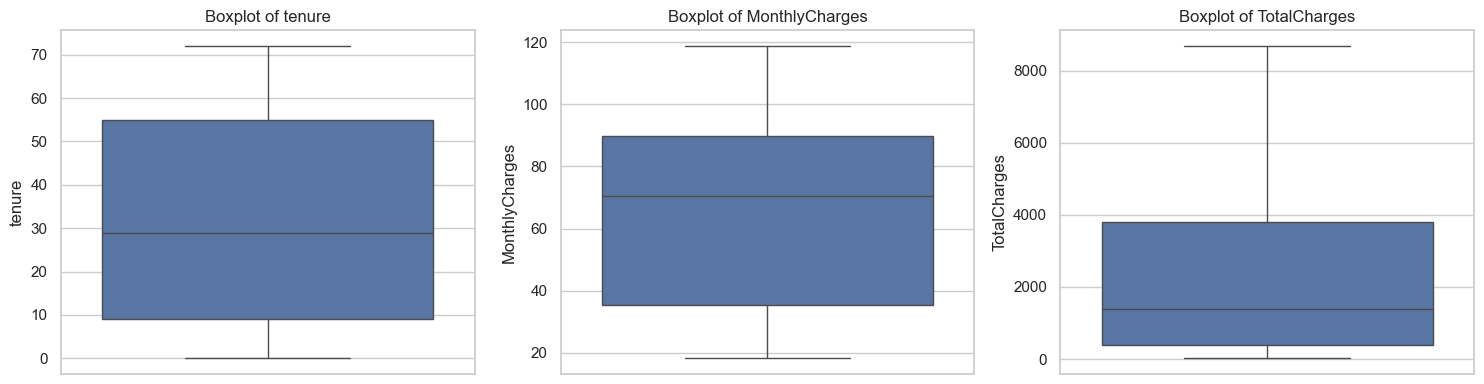

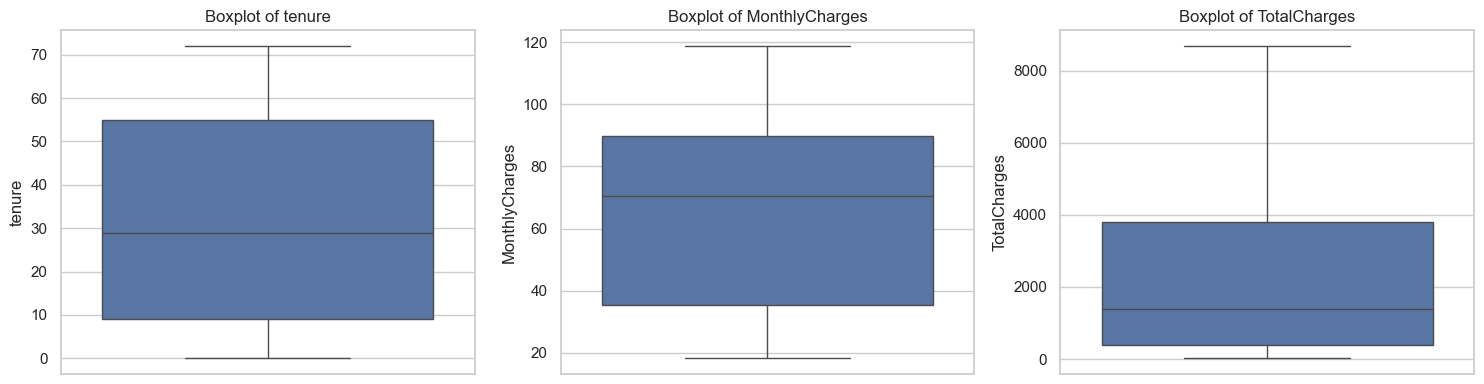

In [11]:
raw_plots.plot_numeric_boxplots(df)

**Conclusion:** None of the numeric columns show extreme or impossible
outliers; the high `TotalCharges` values are simply long-tenure customers, which
are legitimate. We will **not** delete these. Whether any capping helps will be
tested with validation results in later stages rather than assumed.

## 9. Categorical distributions

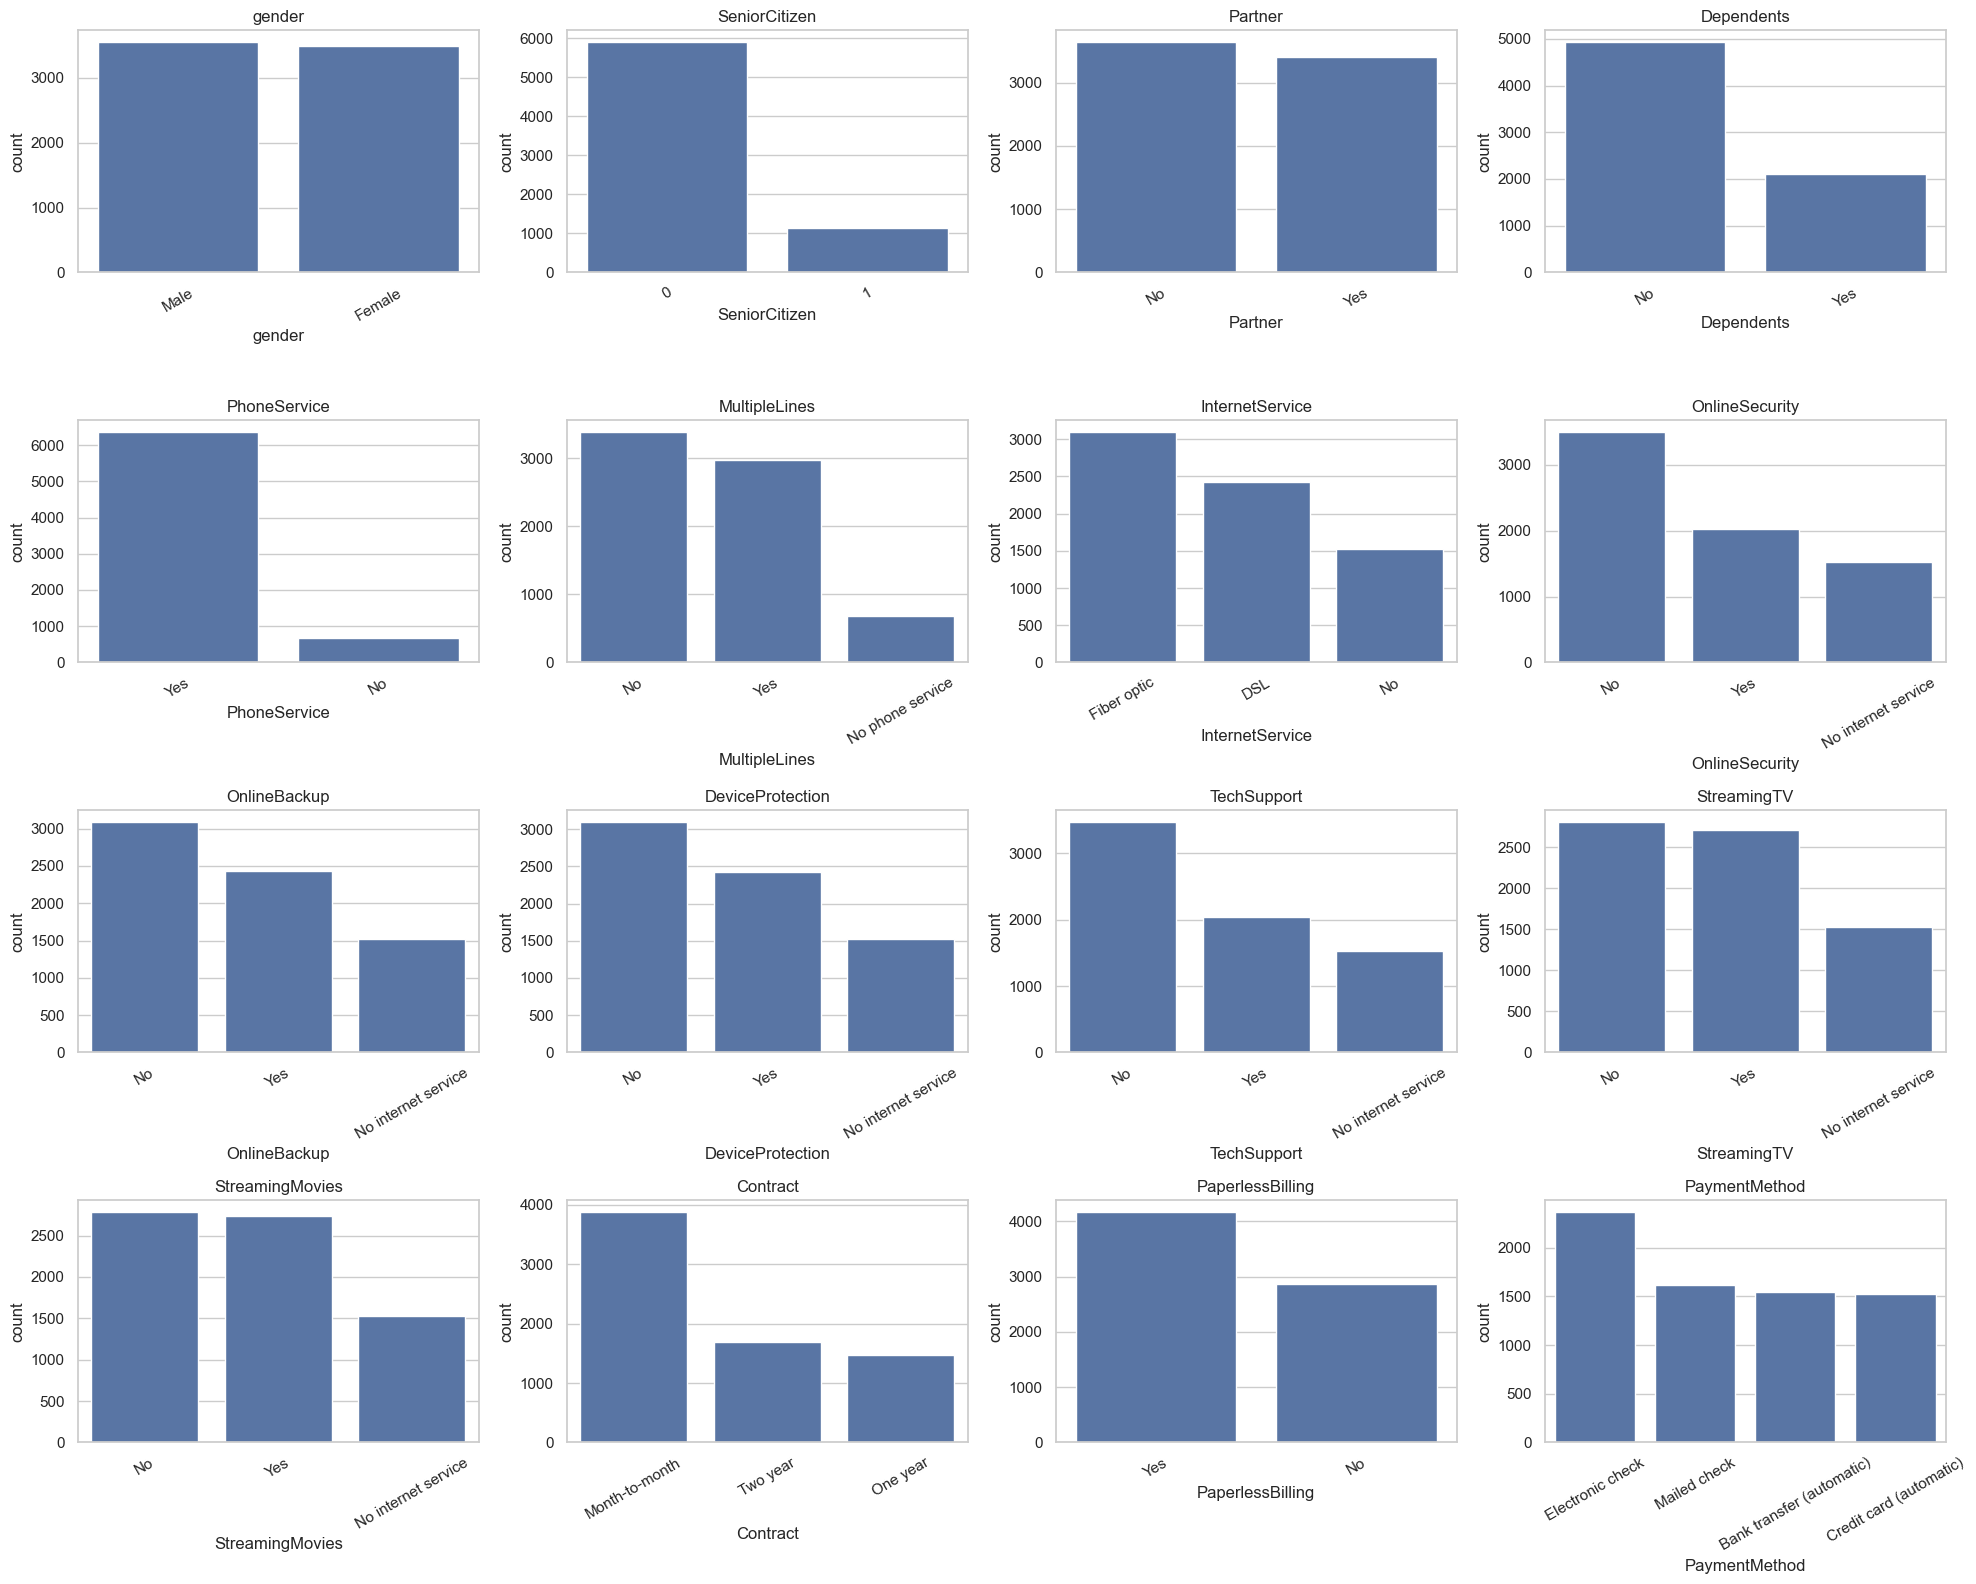

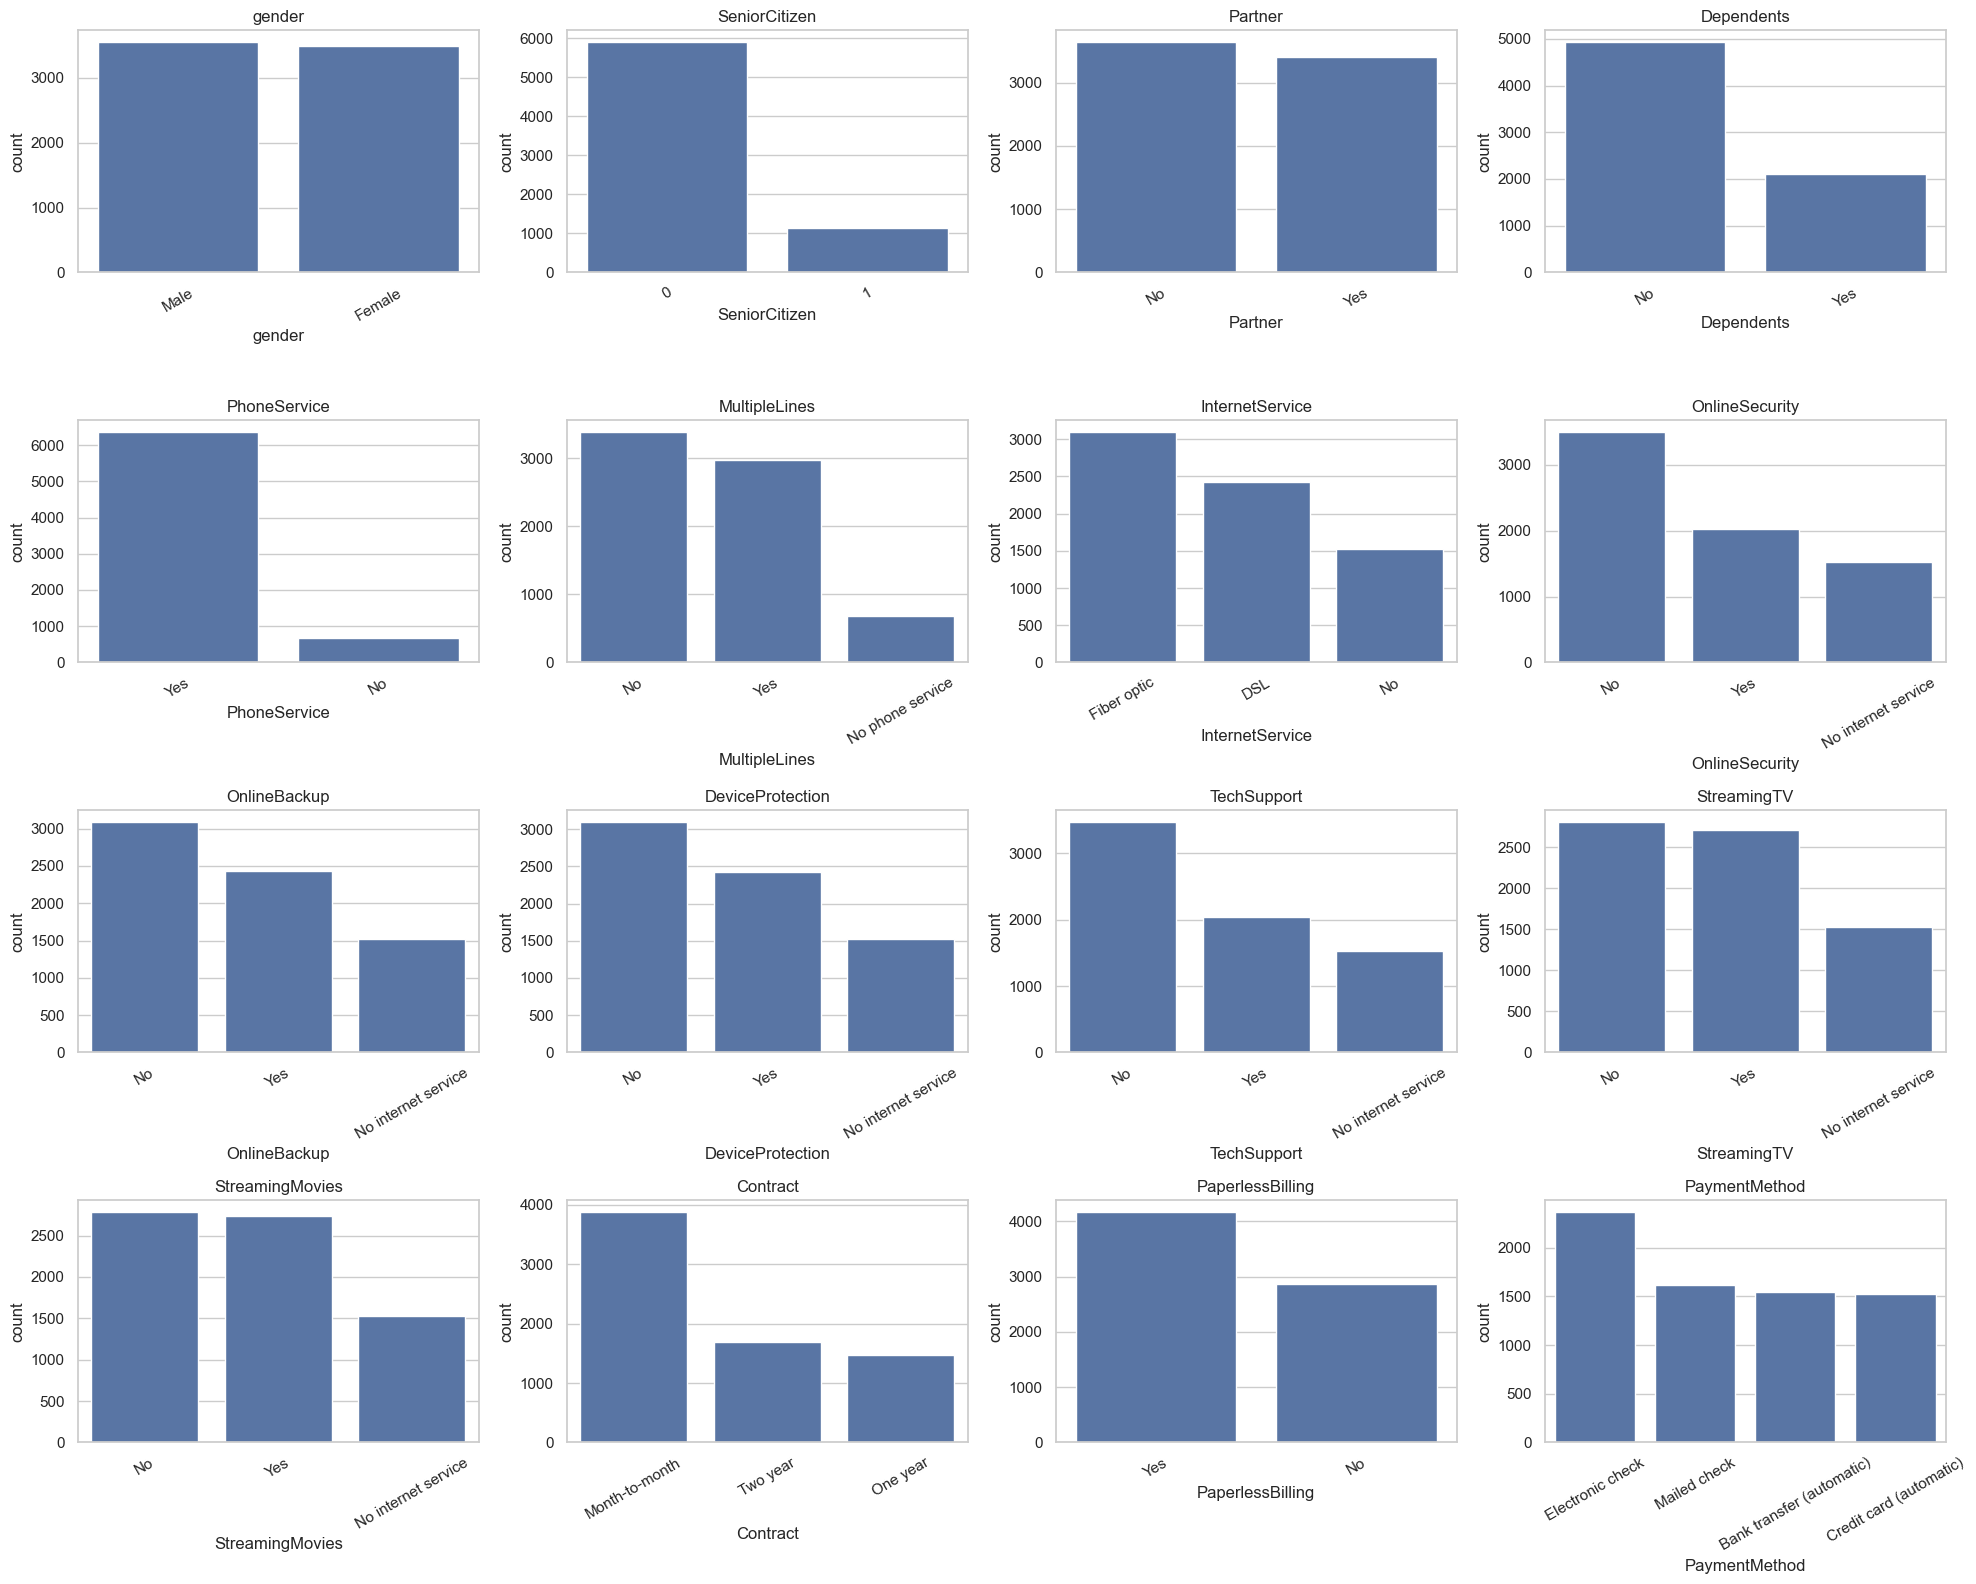

In [12]:
raw_plots.plot_categorical_distributions(df)

**Conclusion:** A few patterns stand out:
- Gender is roughly balanced; most customers are not senior citizens.
- Many service columns include a "No internet service" / "No phone service"
  category, which is really a third state and must be encoded carefully.
- The most common contract is **month-to-month**, and the most common payment
  method is **electronic check** - both are worth watching as churn factors.

## 10. Correlations among numeric features and churn

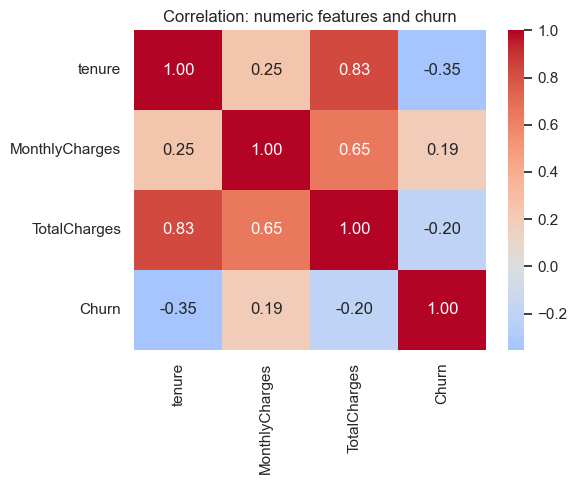

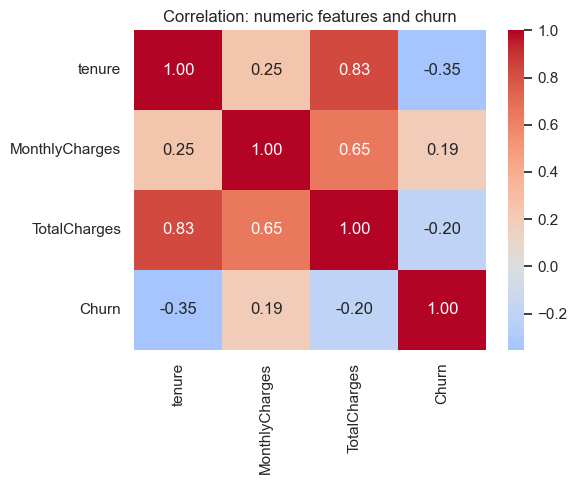

In [13]:
raw_plots.plot_correlation_heatmap(df)

**Conclusion:** `tenure` and `TotalCharges` are strongly correlated (longer
tenure means a larger running total), and both relate to `MonthlyCharges`. Against
churn, longer tenure leans toward staying while higher monthly charges lean toward
leaving. These are **associations, not proven causes**, and we keep that framing
throughout the project.

## 11. Potential leakage and columns that should not be features

- **`customerID`** is a unique identifier. It carries no predictive meaning and
  must be excluded from modeling and from the similarity vectors.
- **`TotalCharges`** is essentially `tenure x MonthlyCharges`. It is not leakage
  (it is known before churn), but its redundancy with tenure will be reviewed for
  multicollinearity in Stage 2.
- There are **no columns recorded after a customer churns** (no cancellation date,
  refund, or exit-survey fields), so there is no obvious target leakage in this
  dataset. The target itself, `Churn`, must of course never be used as an input.

## Summary of Stage 1

What we learned about the raw data:

1. 7,043 customers, 21 columns, mixing numeric and categorical fields.
2. Target `Churn` is imbalanced (~26.5% churned) - drives the metric and
   imbalance-handling choices in Stage 3.
3. `TotalCharges` is text with 11 blank values, all for `tenure = 0` customers -
   a clear, explainable cleaning task for Stage 2.
4. No duplicate rows or duplicate IDs.
5. No extreme/impossible outliers; long-tail charges are legitimate customers.
6. `customerID` is an identifier to drop; no post-churn leakage columns exist.

**Next (Stage 2):** fix `TotalCharges`, drop the identifier from features, and
build one fitted preprocessing pipeline (imputation, encoding, scaling) that every
later stage reuses. No cleaning has been done in this notebook on purpose.